In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
!pip install -U openai-whisper


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 800.5/800.5 kB 11.3 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 51.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 126.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 94.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 58.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 11.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.2 MB/s 

In [3]:
!pip install -U language-tool-python

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.7/54.7 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.1/55.1 kB 3.7 MB/s eta 0:00:00


In [4]:
import os
import pandas as pd
import whisper
import numpy as np
import language_tool_python
from tqdm import tqdm
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

# Load Whisper model (make sure you have whisper installed)
model = whisper.load_model("base")


100%|███████████████████████████████████████| 139M/139M [00:11<00:00, 12.3MiB/s]


In [5]:
# Define the folder where audio files are stored
audio_folder ="/content/drive/MyDrive/train" # Replace with your actual folder
audio_files = [f for f in os.listdir(audio_folder) if f.endswith(".wav") or f.endswith(".mp3")]

# Show audio files
audio_files[:5]

['audio_1019.wav',
 'audio_1005.wav',
 'audio_1012.wav',
 'audio_1015.wav',
 'audio_102.wav']

In [6]:
# Remove Java 11
!sudo apt-get remove openjdk-11-* -y

# Install Java 17
!sudo apt-get update
!sudo apt-get install openjdk-17-jdk -y

# Verify Java version
!java -version


Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
Note, selecting 'openjdk-11-jdk' for glob 'openjdk-11-*'
Note, selecting 'openjdk-11-jre' for glob 'openjdk-11-*'
Note, selecting 'openjdk-11-jre-headless' for glob 'openjdk-11-*'
Note, selecting 'openjdk-11-jdk-headless' for glob 'openjdk-11-*'
Note, selecting 'openjdk-11-demo' for glob 'openjdk-11-*'
Note, selecting 'openjdk-11-source' for glob 'openjdk-11-*'
Note, selecting 'openjdk-11-jre-zero' for glob 'openjdk-11-*'
Note, selecting 'openjdk-11-dbg' for glob 'openjdk-11-*'
Note, selecting 'openjdk-11-doc' for glob 'openjdk-11-*'
Note, selecting 'openjdk-11-jre-dcevm' for glob 'openjdk-11-*'
Package 'openjdk-11-jre-dcevm' is not installed, so not removed
Package 'openjdk-11-dbg' is not installed, so not removed
Package 'openjdk-11-doc' is not installed, so not removed
Package 'openjdk-11-jdk' is not installed, so not removed
Package 'openjdk-11-jre' is not installed, so not removed
Pack

In [ ]:
import os
import pandas as pd
import language_tool_python

tool = language_tool_python.LanguageTool('en-US')

transcriptions = []

for filename in audio_files:
    audio_path = os.path.join(audio_folder, filename)
    result = model.transcribe(audio_path)
    text = result['text']

    # Grammar check
    matches = tool.check(text)
    num_errors = len(matches)
    words = len(text.split()) or 1
    score = max(0, 5 - (num_errors / words * 5))  # Normalize to 0–5 scale

    transcriptions.append({
        "filename": filename,
        "transcription": text,
        "score": round(score, 2)
    })

df = pd.DataFrame(transcriptions)
print(df.head())


         filename                                      transcription  score
0  audio_1019.wav   I have a very large playground in my school. ...   4.90
1  audio_1005.wav   So, the playground is pretty interesting. It'...   4.89
2  audio_1012.wav   The school playground is lively and filled wi...   4.93
3  audio_1015.wav   Ok, Hi who I'm just gonna try to get back to ...   4.13
4   audio_102.wav   I'm sorry. I'm sorry. I'm sorry. I'm sorry. I...   3.50


In [ ]:
df.to_csv("transcriptions_with_scores.csv", index=False)


In [7]:
import pandas as pd
import numpy as np
import language_tool_python
from tqdm import tqdm
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

In [8]:
# 1. Load transcription data
def load_transcriptions(file_path):
    """Load the transcriptions CSV file"""
    return pd.read_csv(file_path)

In [9]:
# 2. Text Feature Extraction with Grammar Analysis
def extract_text_features(text):
    """Extract linguistic features from text"""
    tool = language_tool_python.LanguageTool('en-US')
    matches = tool.check(text)
    words = text.split()
    sentences = [s for s in text.split('.') if s.strip()]
    return {
        'grammar_errors': len(matches),
        'error_rate': len(matches)/len(words) if words else 0,
        'word_count': len(words),
        'unique_words': len(set(words)),
        'lexical_diversity': len(set(words))/len(words) if words else 0,
        'avg_sentence_length': np.mean([len(s.split()) for s in sentences]) if sentences else 0,
        'repetition_score': len(words)/len(set(words)) if words else 1,
        'repetitive_phrases': count_repetitive_phrases(text)
    }

In [10]:
def count_repetitive_phrases(text, min_repeats=3):
    """Count repetitive phrases in text"""
    words = text.split()
    repeats = 0
    for i in range(len(words)-min_repeats):
        if words[i] == words[i+1] == words[i+2]:
            repeats += 1
    return repeats


In [11]:
# 3. Simulate Scores Based on Text Features
def simulate_scores(features):
    """Create synthetic scores based on text features"""
    base_score = 4.0
    score = (
        base_score
        - features['error_rate'] * 2
        - features['repetition_score'] * 0.5
        - features['repetitive_phrases'] * 0.3
    )
    return max(1.0, min(5.0, score))

In [12]:
def process_transcriptions(df):
    """Process all transcriptions with progress tracking"""
    processed = []
    for _, row in tqdm(df.iterrows(), total=len(df)):
        text = row['transcription']
        if not isinstance(text, str) or text.strip() == "":
            continue  # Skip if transcription is not a valid string

        features = extract_text_features(text)
        features['filename'] = row['filename']
        features['transcription'] = text
        features['score'] = simulate_scores(features)
        processed.append(features)
    return pd.DataFrame(processed)


In [13]:
# 5. Modeling and Evaluation
def train_and_evaluate(data):
    X = data.drop(['filename', 'transcription', 'score'], axis=1)
    y = data['score']
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    model = RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42, n_jobs=-1)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print("\nEvaluation Metrics (on synthetic scores):")
    print(f"MSE: {mean_squared_error(y_test, y_pred):.4f}")
    print(f"R²: {r2_score(y_test, y_pred):.4f}")
    plot_feature_importance(model, X.columns)
    return model


In [14]:

def plot_feature_importance(model, feature_names):
    importances = model.feature_importances_
    indices = np.argsort(importances)[-10:]
    plt.figure(figsize=(10, 6))
    plt.title("Top 10 Important Features")
    plt.barh(range(len(indices)), importances[indices], align='center')
    plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
    plt.xlabel("Relative Importance")
    plt.tight_layout()
    plt.show()

Loading and processing transcriptions...


100%|██████████| 210/210 [56:53<00:00, 16.26s/it]



Processed 209 samples
Sample features:
filename            audio_1019.wav
score                     3.239316
grammar_errors                   1
repetition_score          1.444444
Name: 0, dtype: object

Evaluation Metrics (on synthetic scores):
MSE: 0.0238
R²: 0.9701


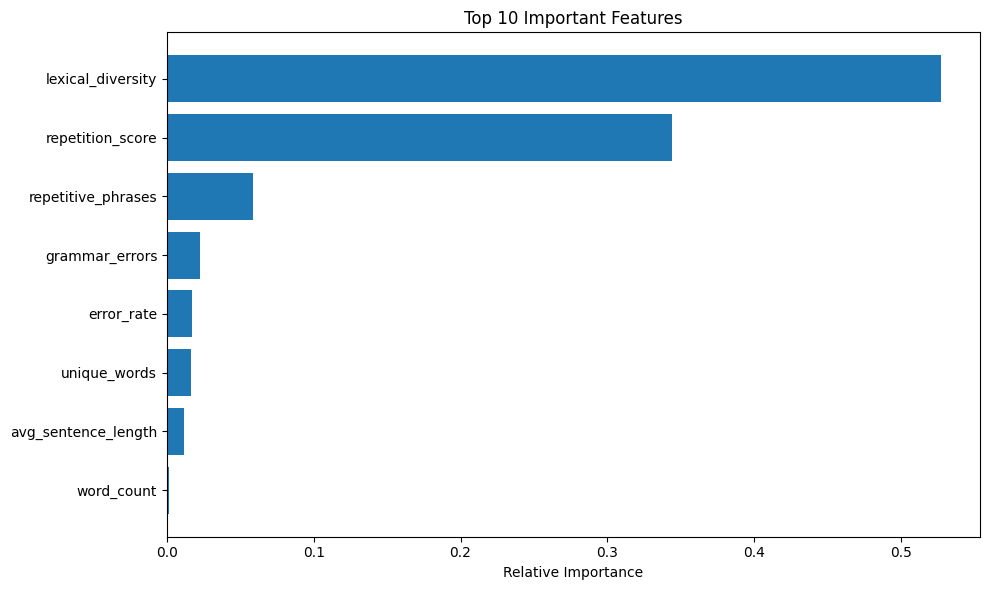


Sample Prediction:
File: audio_1019.wav
Transcription:  I have a very large playground in my school. We play cricket, Kabaddi. In my playground, my PET was...
Grammar Errors: 1
Repetition Score: 1.44
Predicted Score: 3.25


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


In [16]:
TRANSCRIPTIONS_CSV = "/content/transcriptions_with_scores.csv"
print("Loading and processing transcriptions...")
# df = load_transcriptions(TRANSCRIPTIONS_CSV)
# Load and limit to 250 samples
df = load_transcriptions(TRANSCRIPTIONS_CSV).head(210)
processed_data = process_transcriptions(df)
print(f"\nProcessed {len(processed_data)} samples")
print("Sample features:")
print(processed_data.iloc[0][['filename', 'score', 'grammar_errors', 'repetition_score']])
model = train_and_evaluate(processed_data)
sample = processed_data.iloc[0]
sample_features = sample.drop(['filename', 'transcription', 'score'])
prediction = model.predict([sample_features])[0]
print("\nSample Prediction:")
print(f"File: {sample['filename']}")
print(f"Transcription: {sample['transcription'][:100]}...")
print(f"Grammar Errors: {sample['grammar_errors']}")
print(f"Repetition Score: {sample['repetition_score']:.2f}")
print(f"Predicted Score: {prediction:.2f}")

In [17]:
print(processed_data.columns.tolist())


['grammar_errors', 'error_rate', 'word_count', 'unique_words', 'lexical_diversity', 'avg_sentence_length', 'repetition_score', 'repetitive_phrases', 'filename', 'transcription', 'score']


In [18]:
import joblib

# Save model to a file
MODEL_PATH = "/content/random_forest_model_250.pkl"
joblib.dump(model, MODEL_PATH)
print(f"Model saved to {MODEL_PATH}")


Model saved to /content/random_forest_model_250.pkl
